# Проект: классификация

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from  sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing  import LabelEncoder
from sklearn import linear_model 
from sklearn import tree 
from sklearn import ensemble 
from sklearn import metrics 
from sklearn import preprocessing 
from sklearn.model_selection import train_test_split 
from sklearn.feature_selection import SelectKBest, f_classif

## Часть 1. Знакомство с данными, обработка пропусков и выбросов

### Задание 1

**Данные о клиентах банка:**

- age (возраст);
- job (сфера занятости);
- marital (семейное положение);
- education (уровень образования);
- default (имеется ли просроченный кредит);
- housing (имеется ли кредит на жильё);
- loan (имеется ли кредит на личные нужды);
- balance (баланс).

**Данные, связанные с последним контактом в контексте текущей маркетинговой кампании:**

- contact (тип контакта с клиентом);
- month (месяц, в котором был последний контакт);
- day (день, в который был последний контакт);
- duration (продолжительность контакта в секундах).

**Прочие признаки:**

- campaign (количество контактов с этим клиентом в течение текущей кампании);
- pdays (количество пропущенных дней с момента последней маркетинговой кампании до контакта в текущей кампании);
- previous (количество контактов до текущей кампании)
- poutcome (результат прошлой маркетинговой кампании).

И, разумеется, наша целевая переменная deposit, которая определяет, согласится ли клиент открыть депозит в банке. Именно её мы будем пытаться предсказать в данном кейсе.

In [2]:
df = pd.read_csv('bank_fin.csv', sep = ';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,"2 343,00 $",yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,"45,00 $",no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,"1 270,00 $",yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,"2 476,00 $",yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,"184,00 $",no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [3]:
# найдем пропущенные значения,их количество в %, столбцы с ними
display(df.isnull().sum())

display(f'Количество пропусков в признаке "balance":')
display(f'{25} из {df.shape[0]} или {round(25/df.shape[0]*100, 2)}%')

age           0
job           0
marital       0
education     0
default       0
balance      25
housing       0
loan          0
contact       0
day           0
month         0
duration      0
campaign      0
pdays         0
previous      0
poutcome      0
deposit       0
dtype: int64

'Количество пропусков в признаке "balance":'

'25 из 11162 или 0.22%'

### Задание 2

In [4]:
# найдем в признаке job пропущенные значения, которые обозначены специальным словом
display(df['job'].value_counts())

print(f'Количество значений unknown в признаке job: {df[df["job"] == "unknown"].shape[0]}')

job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: count, dtype: int64

Количество значений unknown в признаке job: 70


### Задание 3

In [5]:
# преобразуем признак balance таким образом, чтобы он корректно считывался, как вещественное число (float)
df['balance'] = df['balance'].str.replace('$', '')
df['balance'] = df['balance'].str.replace(' ', '')
df['balance'] = df['balance'].str.replace(',', '.')
df['balance'] = df['balance'].astype (float)

print(round(df["balance"].mean(), 3))

1529.129


### Задание 4

In [6]:
# обработайте пропуски в признаки balance , заменив их на медианные значения по данному признаку
df['balance'].fillna(df['balance'].median(), inplace=True)

print(round(df["balance"].mean(), 3))

1526.936


### Задание 5

In [7]:
# обработайте пропуски в категориальных признаках: job и education, заменив их на модальные значения
job_moda = df['job'].mode()[0]
df['job'] = df['job'].apply(lambda x: job_moda if x == 'unknown' else x)

edu_moda = df['education'].mode()[0]
df['education'] = df['education'].apply(lambda x: edu_moda if x == 'unknown' else x)

# средний баланс для клиентов с самой популярной работой и самым популярным уровнем образования
print(round(df[(df['job'] == job_moda) & (df['education'] == edu_moda)]['balance'].mean(), 3))

1598.883


### Задание 6

In [8]:
# очистим от выбросов признак balance используя метод Тьюки

def find_outliers_iqr(data, feature, left=1.5, right=1.5, log_scale=False):
    """
    Находит выбросы в данных, используя метод межквартильного размаха.
    Классический метод модифицирован путем добавления:
    * возможности логарифмирования распредления
    * ручного управления количеством межквартильных размахов в обе стороны распределения
    Args:
        data (pandas.DataFrame): набор данных
        feature (str): имя признака, на основе которого происходит поиск выбросов
        left (float, optional): количество межквартильных размахов в левую сторону распределения. По умолчанию 1.5.
        right (float, optional): количество межквартильных размахов в правую сторону распределения. По умолчанию 1.5.
        log_scale (bool, optional): режим логарифмирования. По умолчанию False - логарифмирование не применяется.

    Returns:
        pandas.DataFrame: наблюдения, попавшие в разряд выбросов
        pandas.DataFrame: очищенные данные, из которых исключены выбросы
        lower_bound, upper_bound: нижняя и верхняя границы, определяющие выбросы
    """
    if log_scale:
        x = np.log(data[feature]+1)
    else:
        x= data[feature]
    quartile_1, quartile_3 = x.quantile(0.25), x.quantile(0.75),
    iqr = quartile_3 - quartile_1
    lower_bound = quartile_1 - (iqr * left)
    upper_bound = quartile_3 + (iqr * right)
    outliers = data[(x<lower_bound) | (x > upper_bound)]
    cleaned = data[(x>=lower_bound) & (x <= upper_bound)]
    return outliers, cleaned, lower_bound, upper_bound

df_outliers, df_cleaned, lower_bound, upper_bound = find_outliers_iqr(df, 'balance')

print(f'Нижняя граница: {lower_bound}')
print(f'Верхняя граница: {upper_bound}')
print(f'Оставшееся количество объектов после удаления выбросов: {df_cleaned.shape[0]}')

Нижняя граница: -2241.0
Верхняя граница: 4063.0
Оставшееся количество объектов после удаления выбросов: 10105


## Часть 2:  Разведывательный анализ

### Задание 1

deposit
no     5424
yes    4681
Name: count, dtype: int64

Text(0.5, 0.98, 'Распределение целевой переменной (сбалансированность классов)')

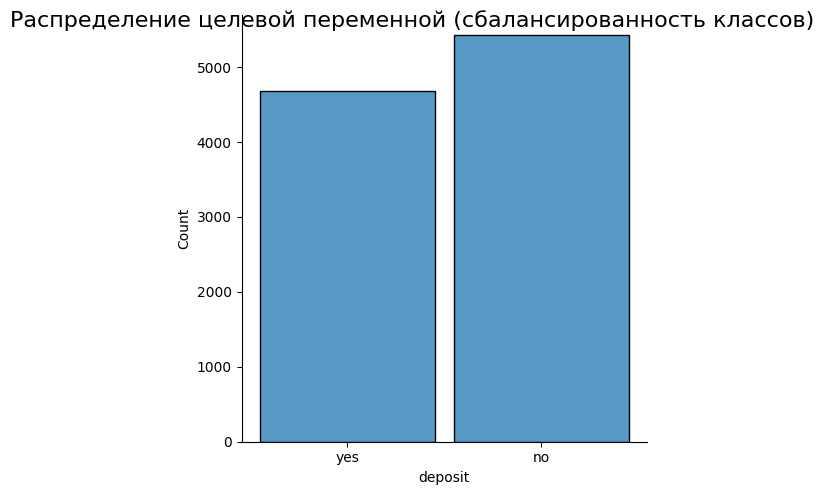

In [9]:
# изучим соотношение классов (распределение целевой переменной) на предмет несбалансированности
display(df_cleaned['deposit'].value_counts())

# построим гисторамму распределения целевой переменной (сбалансированность классов)
dep_hist = sns.displot(df_cleaned, x='deposit', shrink=.9)
dep_hist.figure.suptitle(
    'Распределение целевой переменной (сбалансированность классов)', 
    fontsize=16)

### Задания 2 и 3

In [10]:
#рассчитайте описательные статистики для количественных переменных, проинтерпретируйте результат
df_cleaned.describe()

,age,balance,day,duration,campaign,pdays,previous
count,10105.000000,10105.000000,10105.000000,10105.000000,10105.000000,10105.000000,10105.000000
mean,40.895497,807.653538,15.590302,368.742603,2.517170,51.319644,0.816230
std,11.734931,994.151966,8.441510,346.651524,2.707159,109.644179,2.243795
min,18.000000,-2049.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,95.000000,8.000000,137.000000,1.000000,-1.000000,0.000000
50%,38.000000,445.000000,15.000000,252.000000,2.000000,-1.000000,0.000000
75%,48.000000,1227.000000,22.000000,490.000000,3.000000,2.000000,1.000000
max,95.000000,4063.000000,31.000000,3881.000000,43.000000,854.000000,58.000000


### Задания 4 и 5

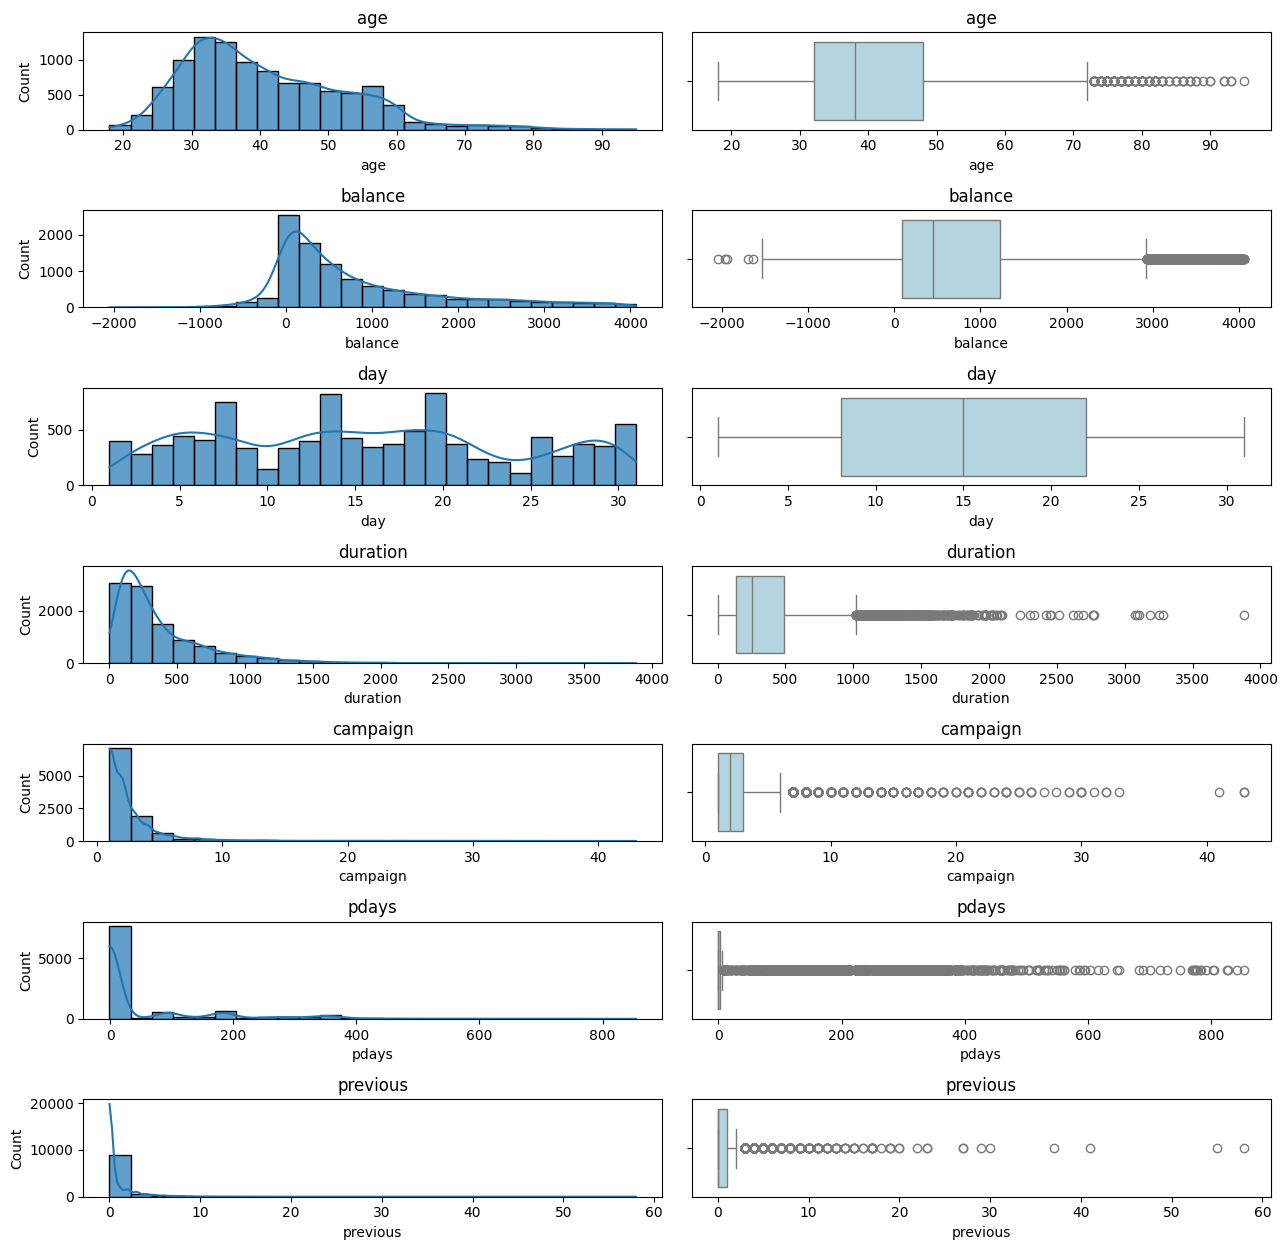

In [11]:
num_features = [col for col in df_cleaned.columns if df_cleaned[col].dtypes != 'O']

fig, axes = plt.subplots(len(num_features), 2, figsize=(13, len(num_features) * 1.8))
if len(num_features) == 1:
    axes = axes.reshape(1, -1)

for i, col in enumerate(num_features):
    sns.histplot(df_cleaned[col], bins=25, kde=True, ax=axes[i, 0], alpha=0.7)
    axes[i, 0].set_title(col)
    
    sns.boxplot(x=df_cleaned[col], ax=axes[i, 1], color='lightblue')
    axes[i, 1].set_title(col)

plt.tight_layout()
plt.show()

**Выводы для количественных переменных:**
- Возраст (age). Пик возраста приходится на 30-40 лет, после 60 идет резкое снижение количества наблюдений.
- Баланс (balance). Для баланса характерно наличие отрицательных значений, большее количество наблюдений сконцентрировано в нулевых и близких к ним значениях. Клиенты не стремятся хранить большие суммы в банке.
- День, в который был последний контакт (day). Распределение близко к равномерному, просматриваются "взлеты" количетсва значений, но в основном это ровные учатски в начале, середине и конце месяца.
- Продолжительность контактов (duration). Продолжительность контакта в среднем 4-5 минут, контакты более 25 минут - предполагаемые выбросы.
- Количество контактов (campaign). Количество контактов во время компании более 15 - предполагаемые выбросы.
- Количество дней с момента предыдущей компании (pdays). Выбросами можно считать значения свыше 400.
- Количество предыдущих контактов (previous). Аналогично campaign - выбросы - значения более 15.

In [12]:
print(f"Число месяцев маркетинговой кампании: {df_cleaned['month'].nunique()}")
print(f"Месяцы маркетинговой кампании: {df_cleaned['month'].unique()}")

Число месяцев маркетинговой кампании: 12
Месяцы маркетинговой кампании: ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']


In [13]:
print(f"Число сфер занятости представлено среди клиентов банка: {df_cleaned['job'].nunique()}")
print(f"Сферы занятости среди клиентов банка: {df_cleaned['job'].unique()}")

Число сфер занятости представлено среди клиентов банка: 11
Сферы занятости среди клиентов банка: ['admin.' 'technician' 'services' 'management' 'retired' 'blue-collar'
 'unemployed' 'entrepreneur' 'housemaid' 'self-employed' 'student']


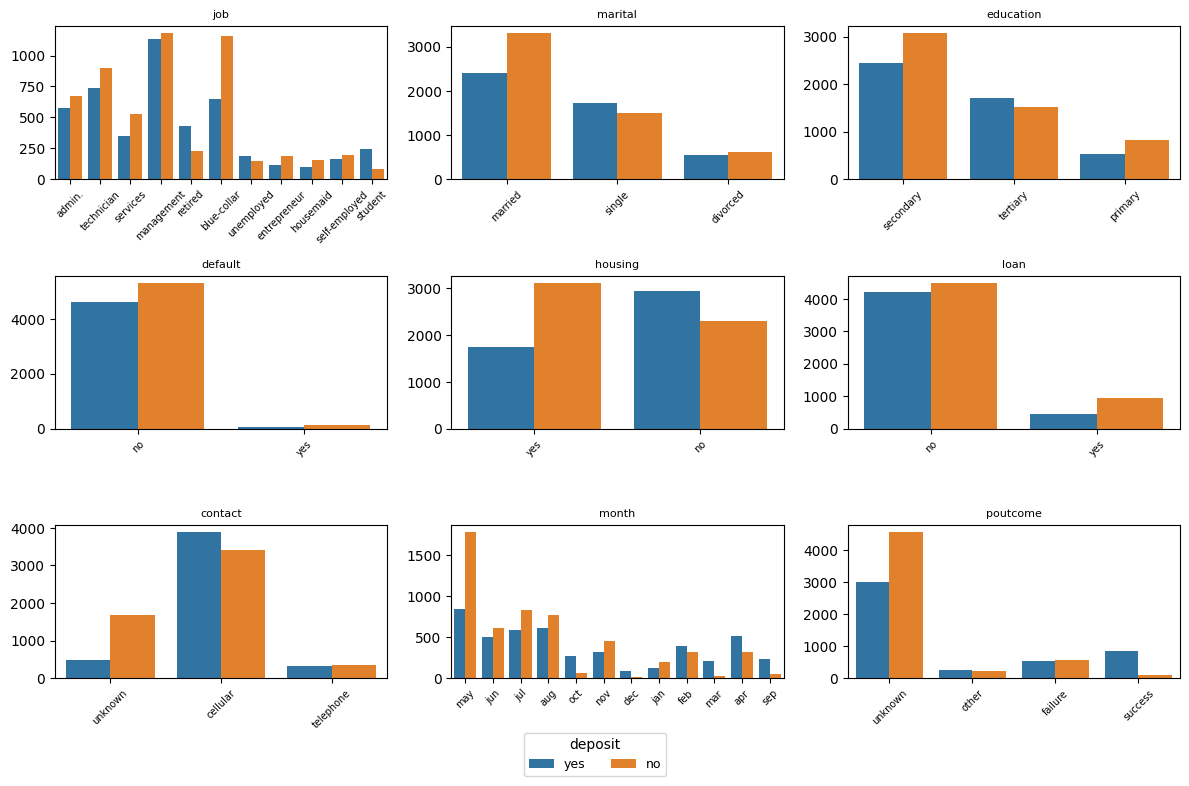

In [14]:
# рассчитайте описательные статистики для категориальных переменных, проинтерпретируйте результат
cat_cols = [col for col in df_cleaned.columns if df_cleaned[col].dtypes == 'O' and col != 'deposit']

n_rows = (len(cat_cols) + 2) // 3
fig, axes = plt.subplots(n_rows, 3, figsize=(12, n_rows * 2.5))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df_cleaned, x=col, hue='deposit', ax=axes[i])
    axes[i].set_title(col, fontsize=8)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].tick_params(axis='x', rotation=45, labelsize=7)
    axes[i].legend().remove()

for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

# легенда внизу
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='deposit', loc='lower center', 
          bbox_to_anchor=(0.5, -0.05), ncol=2, fontsize=9)

plt.tight_layout()
plt.show()

**Выводы для категориальных переменных**
- Студенты и пенсионеры чаще открывают депозит, чем представители других сфер занятости. 
- Для категории "single" более характерно брать депозит, чем "married/divorced". Но в количестве превалируют клиенты в статусе "married".
- Наиболее популярная группа по уровню образования - "secondary", но наболее склонны брать депозит внутри группы люди с образованием "tertiary".
- Среди опрошенных в основном люди без потребительских кредитов и просрочек по кредитам.
- Более вероятно, что депозит возмут те, у кого нет кредита на жилье.
- Наиболее склонны к оформлению депозита клиенты, с которыми связались по мобильному.
- Наибольшее количество наблюдений по результатам предыдущей компании незвестны, но те, кто согласился в прошлый раз, более склонны вновь сказать "да".
- Наибольший процент отказов наблюдается в мае и в летние месяцы, в остальное время, кроме ноября, доля согласившихся на открытие депозита больше, чем отказавшихся.

### Задание 6

In [15]:
# Узнайте, для какого статуса предыдущей маркетинговой кампании успех в текущей превалирует над количеством неудач.
df_cleaned.groupby('poutcome')['deposit'].value_counts().unstack()

deposit,no,yes
poutcome,,
failure,562,547
other,216,265
success,84,861
unknown,4562,3008


### Задание 7

Text(0.5, 1.0, 'Распределение month для отказов от открытия депозита')

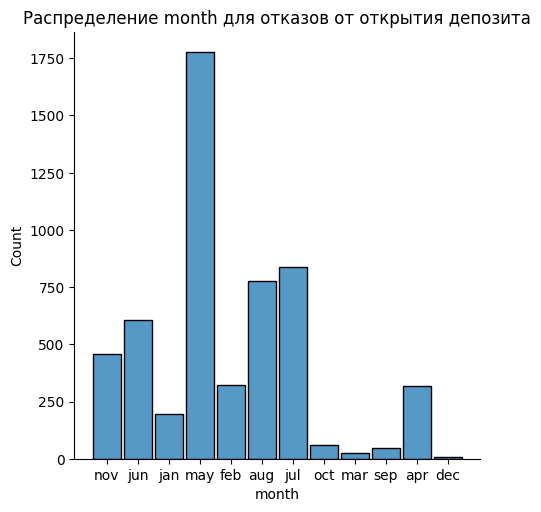

In [16]:
# узнайте, в каком месяце чаще всего отказывались от предложения открыть депозит
mon_hist = sns.displot(df_cleaned[df_cleaned['deposit'] == 'no'], x='month', shrink=.9)
mon_hist.ax.set_title('Распределение month для отказов от открытия депозита')

### Задание 8

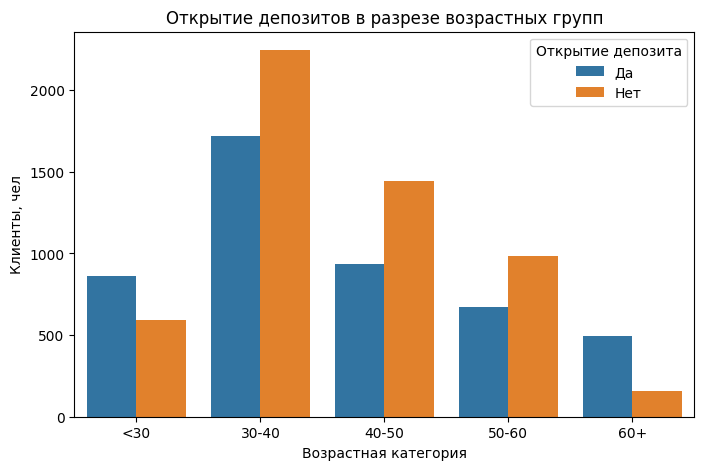

In [17]:
# создайте возрастные группы и определите, в каких группах более склонны открывать депозит, чем отказываться от предложения
df_cleaned['age_group'] = pd.cut(
    df_cleaned['age'],
    bins=[0, 30, 40, 50, 60, 200], 
    labels=['<30', '30-40', '40-50', '50-60', '60+'],
    include_lowest=True,                                # включать нижнюю (левую) границу
    right=False                                         # НЕ включать верхнюю (правую) границу
)

def plot_count(
        x_data_:str, 
        title_:str, xlabel_:str,
        figsize_:tuple=(8, 5), 
        df_:pd.DataFrame=df_cleaned, 
        col_:pd.Series='deposit'
    ) -> None:
    """ Функция построения столбчатой диаграммы для отложения заданного столбца данных по оси x 
        в зависимости от открытия / неоткрытия депозита 

    Args:
        x_data_ (str): признак (колонка) с данными для построения графика на оси x
        
        title_ (str): заголовок графика
        
        xlabel_ (str): заголовок оси x

        figsize_ (tuple): размеры координатной сетки. Defaults to (8, 5).
        
        df_ (pd.DataFrame): исходный датафрейм. Defaults to df.
        
        col_ (pd.Series, optional): столбец принадлежности к категории открытия / неоткрытия депозита. 
                                    Defaults to 'deposit'.
    """

    # координатная сетка
    fig, axes = plt.subplots(1, 1, figsize=figsize_)
    
    # данные для построения графика
    ax_count = sns.countplot(
        data=df_, 
        x=x_data_, 
        hue=col_
    )

    # подписи осей и заголовок
    ax_count.set(
        title='Открытие депозитов в разрезе ' + title_,
        ylabel='Клиенты, чел',
        xlabel=xlabel_
    )

    # заголовок легенды и имена категорий
    ax_count.legend(
        ['Да', 'Нет'],
        title='Открытие депозита'
    )

plot_count('age_group', 'возрастных групп', 'Возрастная категория')

Склонны открывать кредит группы в возрасте <30 лет и 60+.

### Задания 9 и 10

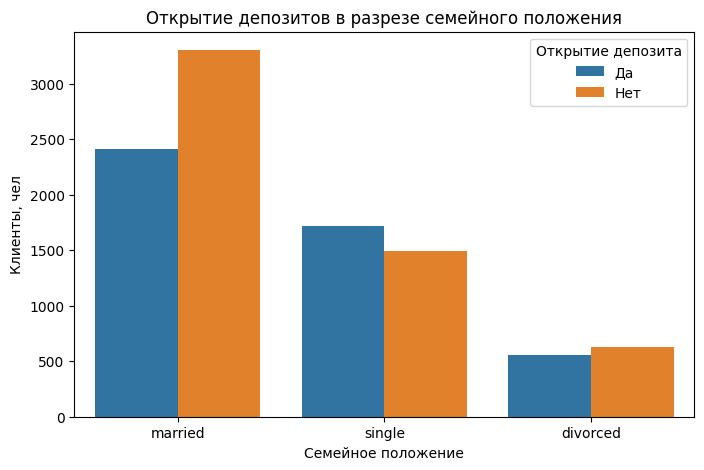

In [18]:
# постройте визуализации для открывших и неоткрывших депозит в зависимости от семейного статуса
plot_count('marital', 'семейного положения', 'Семейное положение')

Для категории "single" есть тенденция открывать депозит, а не отказываться от его открытия.

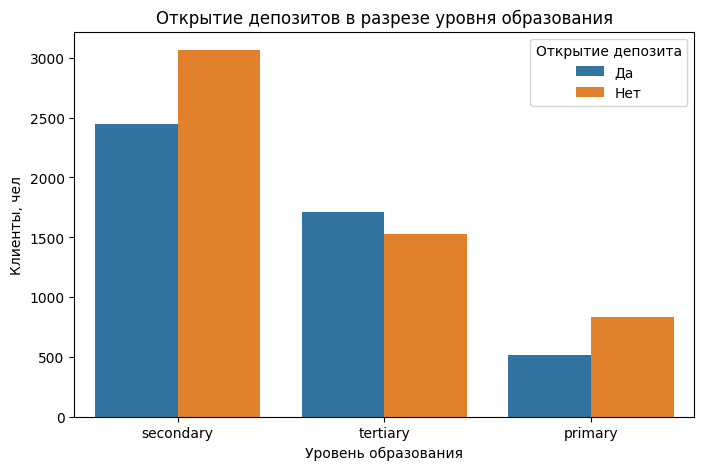

In [19]:
# постройте визуализации для открывших и неоткрывших депозит в зависимости от образования
plot_count('education', 'уровня образования', 'Уровень образования')

Для категории "tertiary" есть тенденция открывать депозит, а не отказываться от его открытия.

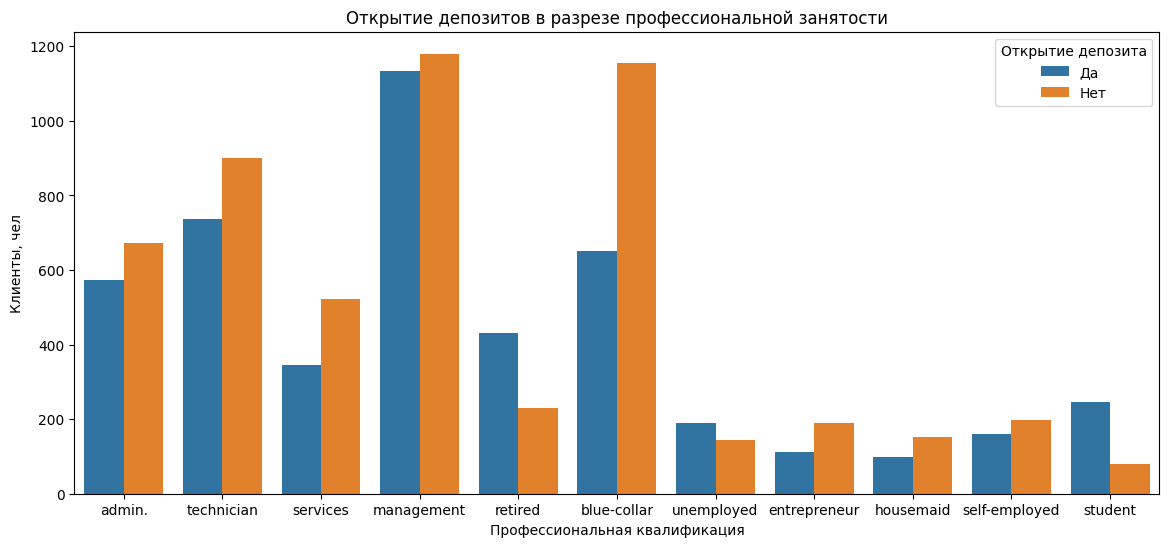

In [20]:
# постройте визуализации для открывших и неоткрывших депозит в зависимости от вида профессиональной занятости
plot_count('job', 'профессиональной занятости', 'Профессиональная квалификация', (14, 6))

In [21]:
df_job_mode = df_cleaned['job'].value_counts()
print(f"Самая распространённая сфера занятости: '{df_job_mode.idxmax()}'")

Самая распространённая сфера занятости: 'management'


### Задание 11

marital,divorced,married,single
education,,,
primary,96,339,82
secondary,283,1289,879
tertiary,174,784,755


marital,divorced,married,single
education,,,
primary,91,641,100
secondary,370,1830,866
tertiary,163,832,531


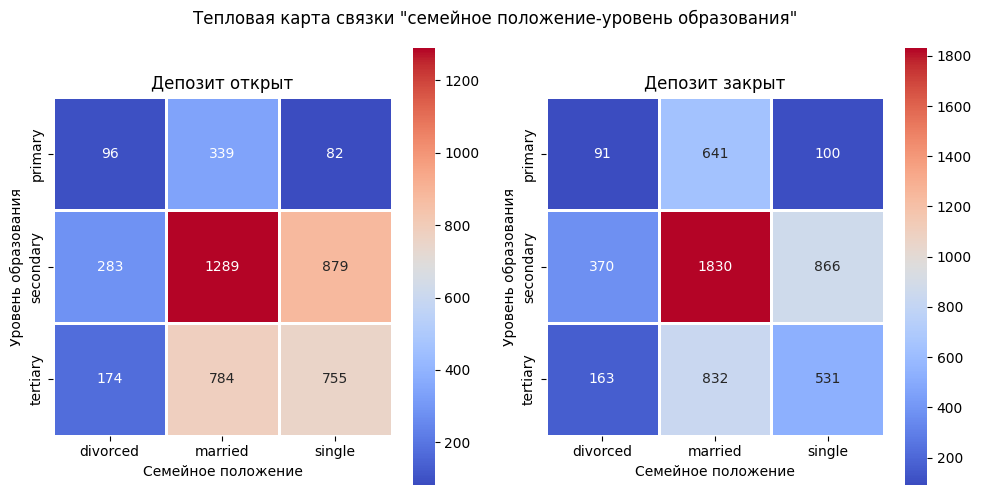

In [22]:
# постройте сводную таблицу, чтобы определить люди с каким образованием и семейным статусом наиболее многочисленны
# (если рассматривать тех, кто открыл депозит)

def plot_heatplot(
        yn_:str, 
        subplot_title:str, 
        ax_:plt.Axes, 
        df_:pd.DataFrame=df_cleaned
    ) -> pd.DataFrame | plt.Axes:
    """ Функция формирования сводного датафрейма и вывода тепловой карты

    Args:
        yn_ (str): значение признака 'deposit' - 'yes' | 'no'

        subplot_title (str): подзаголовок графика

        ax_ (plt.Axes): подпространство осей, где строить график

        df_ (pd.DataFrame, optional): исходный датафрейм. Defaults to df.

    Returns:
        pivot (pd.DataFrame):   сводный датафрейм

        ax_heat_ (plt.Axes):    график-"тепловая карта"
    """
    # сводный датафрейм
    pivot = df_[df_['deposit'] == yn_] \
        .groupby(['education', 'marital']
        )['marital'] \
        .count() \
        .unstack()
    
    # тепловая карта
    ax_heat_ = sns.heatmap(
        pivot, 
        annot=True, 
        square=True,
        fmt='.0f', 
        linewidths=1, 
        cmap='coolwarm', 
        ax=ax_
    )

    # подписи осей и заголовок графика
    ax_heat_.set(
        title=subplot_title,
        xlabel='Семейное положение', 
        ylabel='Уровень образования'
    )
    return pivot, ax_heat_

# строим графики на одной координатной плоскости
fig, ax_heat = plt.subplots(1, 2, figsize=(10, 5))
pivot_yes, ax_heat[0] = plot_heatplot('yes', 'Депозит открыт', ax_heat[0])
pivot_no, ax_heat[1] = plot_heatplot('no', 'Депозит закрыт', ax_heat[1])

# общий для графиков заголовок
plt.suptitle('Тепловая карта связки "семейное положение-уровень образования"')

# выводим сводные таблицы
display(pivot_yes, pivot_no)

# выравниваем графики
plt.tight_layout();

## Часть 3: преобразование данных

### Задание 1

In [23]:
# создание экземпляра класса LabelEncoder()
lbl_enc = preprocessing.LabelEncoder()

# кодирование признака 'education'
df_cleaned['education'] = lbl_enc.fit_transform(df_cleaned['education'])

# преобразование типа признака в 'int8'
df_cleaned['education'] = df_cleaned['education'].astype('int8')

print(f"Сумма значений признака 'education': {df_cleaned['education'].sum()}")

Сумма значений признака 'education': 11995


In [24]:
# кодирование признака 'age_group'
df_cleaned['age_group'] = lbl_enc.fit_transform(df_cleaned['age_group'])

# преобразование типа признака в 'int8'
df_cleaned['age_group'] = df_cleaned['age_group'].astype('int8')

### Задания 2 и 3

In [25]:
# преобразуйте бинарные переменные в представление из нулей и единиц
df_cleaned['deposit'] = df_cleaned['deposit'].apply(lambda x: 1 if x == 'yes' else 0)
df_cleaned['default'] = df_cleaned['default'].apply(lambda x: 1 if x == 'yes' else 0)
df_cleaned['housing'] = df_cleaned['housing'].apply(lambda x: 1 if x == 'yes' else 0)
df_cleaned['loan'] = df_cleaned['loan'].apply(lambda x: 1 if x == 'yes' else 0)

# преобразование типа признака в 'int8'
df_cleaned['deposit'] = df_cleaned['deposit'].astype('int8')
df_cleaned['default'] = df_cleaned['default'].astype('int8')
df_cleaned['housing'] = df_cleaned['housing'].astype('int8')
df_cleaned['loan'] = df_cleaned['loan'].astype('int8')

In [26]:
# вычислим стандартное отклонение признака deposit
round(df_cleaned['deposit'].std(), 3)

0.499

In [27]:
# вычислим сумму стандартных отклонений признаков:
# default, housing, loan
round(df_cleaned['default'].mean() + df_cleaned['housing'].mean() + df_cleaned['loan'].mean(), 3)

0.635

### Задание 4

In [28]:
# создайте дамми-переменные
# выбираем колонки типа 'object'
object_cols = list(df_cleaned.select_dtypes(['object']).columns)

# кодируем признаки
df_dummies = pd.get_dummies(df_cleaned[object_cols])

# соединяем с основным датафреймом
df_cleaned = pd.concat([df_cleaned, df_dummies], axis=1)

In [29]:
print(f"Всего признаков, кроме целевого: {df_cleaned.shape[1] - 1}")

Всего признаков, кроме целевого: 50


In [30]:
# удаляем исходные признаки типа 'object'
df_cleaned.drop(columns=object_cols, inplace=True)

### Задания 5 и 6

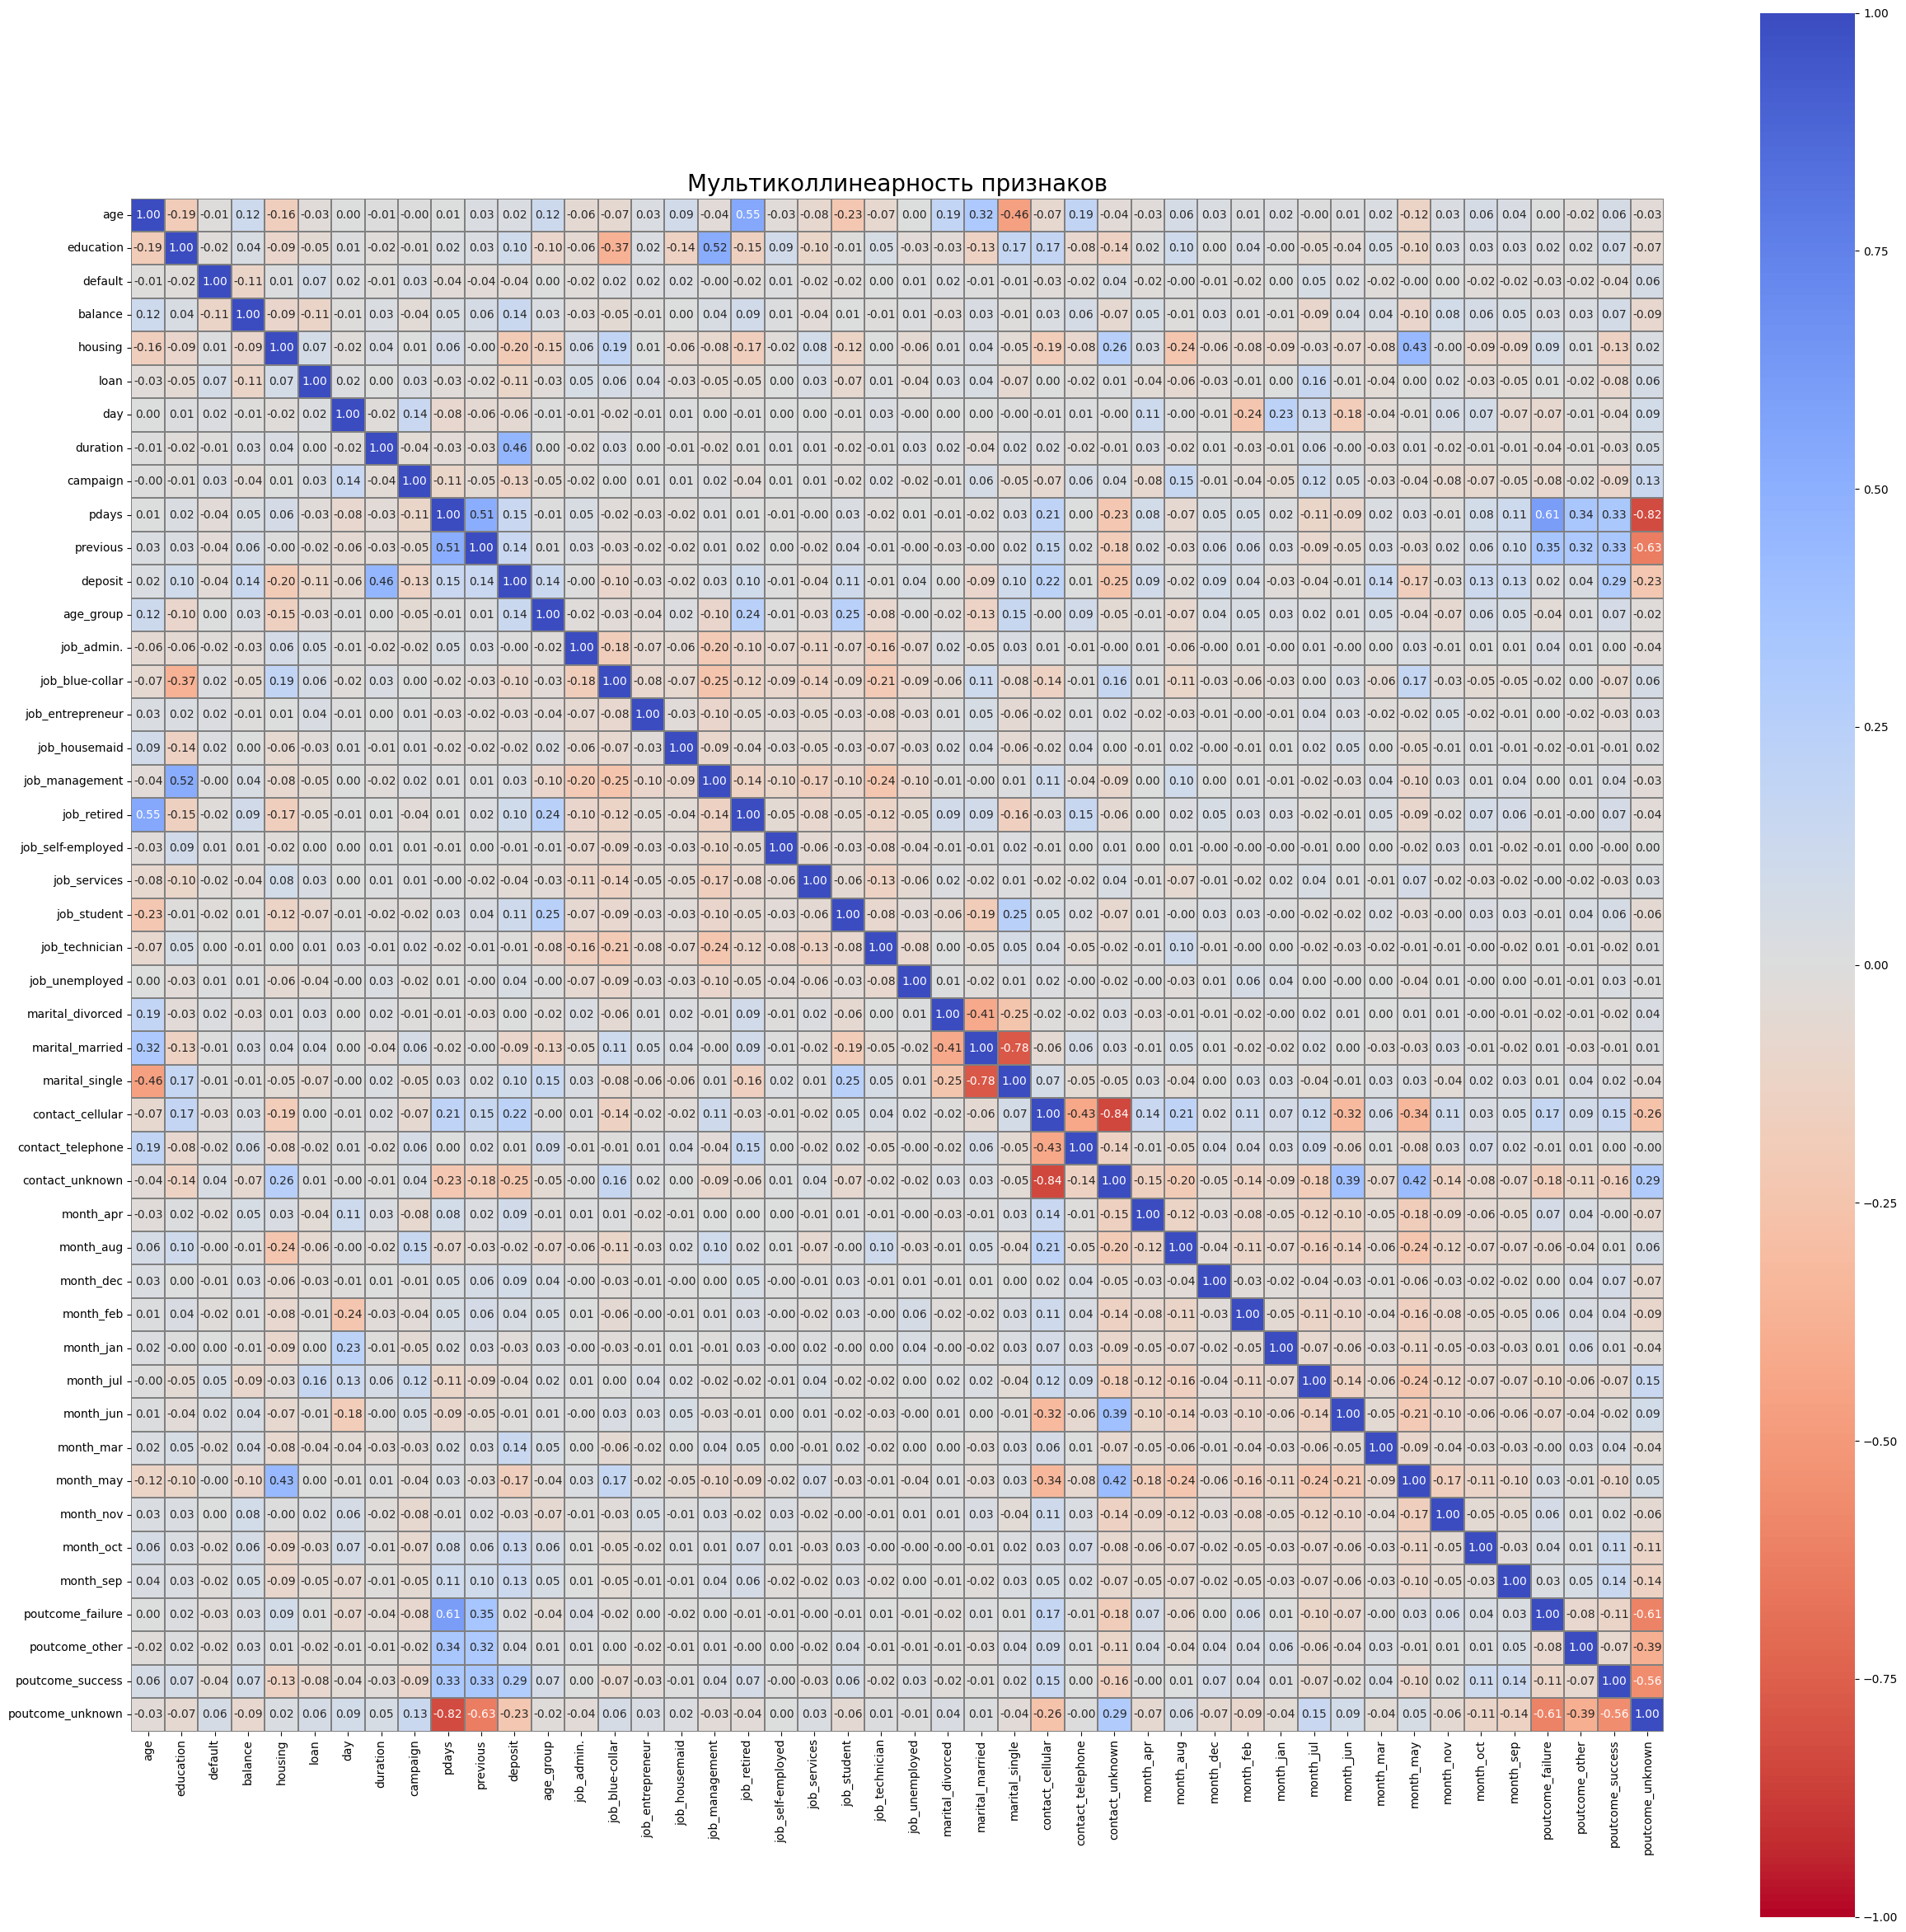

In [31]:
# постройте корреляционную матрицу и оцените данные на предмет наличия мультиколлинеарности

# данные для построения графика
df_corr = df_cleaned.corr()
plt.subplots(figsize=(30, 30))

# график - тепловая матрица с коэффициентами корреляции не менее 0.9
ax_heat_multicoll = sns.heatmap(
    # df_corr[df_corr.abs() >= 0.9],        # для вывода матрицы корреляции с коэффициентами не менее 0.9
    df_corr,
    vmin=-1, 
    vmax=1, 
    linewidth=0.05, 
    linecolor='gray', 
    cmap='coolwarm_r',
    annot = True,
    fmt='.2f',
    square=True
)

# задаём заголовок
ax_heat_multicoll.set_title('Мультиколлинеарность признаков', fontsize=20);

In [32]:
corr_matrix = df_cleaned.corr()

# Создаём маску для верхнего треугольника
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
corr_pairs = corr_matrix.where(mask).stack().sort_values(key=abs, ascending=False)

print("="*50)
print("4 НАИБОЛЕЕ КОРРЕЛИРУЕМЫХ ПРИЗНАКА")
print("="*50)
for i, ((feat1, feat2), corr_val) in enumerate(corr_pairs.head(4).items(), 1):
    print(f"{i}. {feat1} ↔ {feat2}: {corr_val:.3f}")

4 НАИБОЛЕЕ КОРРЕЛИРУЕМЫХ ПРИЗНАКА
1. contact_cellular ↔ contact_unknown: -0.838
2. pdays ↔ poutcome_unknown: -0.824
3. marital_married ↔ marital_single: -0.779
4. previous ↔ poutcome_unknown: -0.628


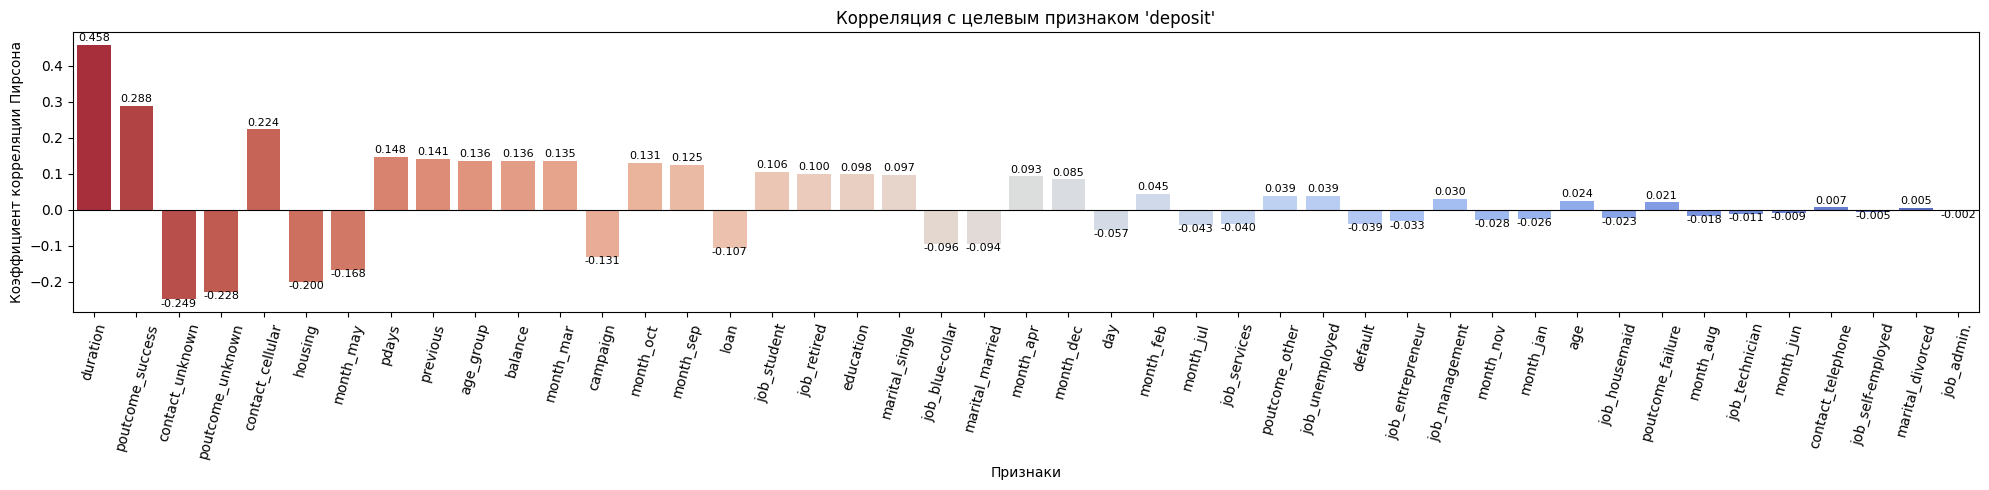

In [33]:
df_corr = df_cleaned.corr()
plot_df = df_corr.drop('deposit')
feature_order = abs(plot_df['deposit']).sort_values(ascending=False).index

plt.figure(figsize=(20, 5))
ax = sns.barplot(x=plot_df.reset_index()['index'], y='deposit', data=plot_df.reset_index(),
                  order=feature_order, palette='coolwarm_r')
ax.set(title="Корреляция с целевым признаком 'deposit'", 
       xlabel='Признаки', ylabel='Коэффициент корреляции Пирсона')
ax.tick_params(axis='x', rotation=75)
ax.axhline(y=0, color='black', linewidth=0.8)

# Добавляем значения на столбцы
for i, (idx, val) in enumerate(plot_df['deposit'].reindex(feature_order).items()):
    ax.text(i, val + (0.01 if val > 0 else -0.02), f'{val:.3f}', 
            ha='center', fontsize=8)

plt.tight_layout()
plt.show()

- Среди признаков отсутствует мультиколлинеарность (корреляция менее 0.9). 
- Наиболее коррелированы с целевым признаком переменные: duration, poutcome_success, contact_cellular (по убыванию силы линейной взаимосвязи).

### Задания 7 и 8

In [34]:
X = df_cleaned.drop(['deposit'], axis=1)
y = df_cleaned['deposit']
 
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state = 42, test_size = 0.33)

In [35]:
print(f'Размер тествовой выборки: {X_test.shape[0]}')
print(f'Среднее значение целевой переменной на тестовой выборке: {round(y_test.mean(), 2)}')

Размер тествовой выборки: 3335
Среднее значение целевой переменной на тестовой выборке: 0.46


### Задание 9

In [36]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10105 entries, 0 to 11161
Data columns (total 46 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                10105 non-null  int64  
 1   education          10105 non-null  int8   
 2   default            10105 non-null  int8   
 3   balance            10105 non-null  float64
 4   housing            10105 non-null  int8   
 5   loan               10105 non-null  int8   
 6   day                10105 non-null  int64  
 7   duration           10105 non-null  int64  
 8   campaign           10105 non-null  int64  
 9   pdays              10105 non-null  int64  
 10  previous           10105 non-null  int64  
 11  deposit            10105 non-null  int8   
 12  age_group          10105 non-null  int8   
 13  job_admin.         10105 non-null  bool   
 14  job_blue-collar    10105 non-null  bool   
 15  job_entrepreneur   10105 non-null  bool   
 16  job_housemaid      10105 no

In [37]:
# с помощью SelectKBest отберите 15 наиболее подходящих признаков
from sklearn import feature_selection
# задаём объект класса SelectKBest с k=15, 
# score_func : callable, default=f_classif
selector_skb_15 = feature_selection.SelectKBest(score_func = f_classif, k=15)
selector_skb_15.fit(X_train, y_train)

# забираем отобранные признаки
selector_skb_cols = selector_skb_15.get_feature_names_out()

# вывод отобранных признаков
print(f'Отобранные признаки:\n {selector_skb_cols}')

# преобразование выборок
X_train = X_train[selector_skb_cols]
X_test = X_test[selector_skb_cols]

Отобранные признаки:
 ['balance' 'housing' 'duration' 'campaign' 'pdays' 'previous' 'age_group'
 'contact_cellular' 'contact_unknown' 'month_mar' 'month_may' 'month_oct'
 'month_sep' 'poutcome_success' 'poutcome_unknown']


In [38]:
months = {'month_mar', 'month_may', 'month_oct', 'month_sep', 'month_jan'}

print(f"Не попала в перечень переменная: '{list(months.difference(set(selector_skb_cols)))[0]}'")

Не попала в перечень переменная: 'month_jan'


### Задание 10

In [39]:
# нормализуйте данные с помощью minmaxsxaler
# задаём объект класса для скейлера
MMS_scaler = preprocessing.MinMaxScaler()

# обучаем скейлер, подгоняем данные
MMS_scaler.fit(X_train)

# транформируем данные обученным скейлером
X_train_scaled = MMS_scaler.transform(X_train)
X_test_scaled = MMS_scaler.transform(X_test)

In [40]:
# Задание 4.10. Рассчитайте среднее арифметическое для первого предиктора (т. е. для первого столбца матрицы) из тестовой выборки. 
# Ответ округлите до двух знаков после точки-разделителя.

print(f'Среднее первого предиктора из тестовой выборки: {X_test_scaled[:, 0].mean().__round__(2)}')

Среднее первого предиктора из тестовой выборки: 0.47


# Часть 4: Решение задачи классификации: логистическая регрессия и решающие деревья

### Задание 1

In [55]:
# обучим логистическую регрессию и рассчитаем метрику качества accuracy
lr = linear_model.LogisticRegression(
                                     solver='sag', 
                                     random_state=42, 
                                     max_iter=1000
                                     )
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print(f'Значение метрики для тестовой выборки: \n \n {(metrics.classification_report(y_test, y_pred_lr, digits=3))}')

Значение метрики для тестовой выборки: 
 
               precision    recall  f1-score   support

           0      0.790     0.866     0.826      1790
           1      0.825     0.734     0.777      1545

    accuracy                          0.805      3335
   macro avg      0.808     0.800     0.802      3335
weighted avg      0.807     0.805     0.804      3335



### Задания 2,3,4

In [56]:
# обучите решающие деревья, настройте максимальную глубину
dt = tree.DecisionTreeClassifier(criterion='entropy', random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_train = dt.predict(X_train_scaled)
y_pred_test = dt.predict(X_test_scaled)

print(f'Метрики для тренировочной выборки: \n \n {metrics.classification_report(y_train, y_pred_train, digits=3)}')
print()
print(f'Метрики для тестовой выборки: \n \n{metrics.classification_report(y_test, y_pred_test, digits=3)}')

Метрики для тренировочной выборки: 
 
               precision    recall  f1-score   support

           0      1.000     1.000     1.000      3634
           1      1.000     1.000     1.000      3136

    accuracy                          1.000      6770
   macro avg      1.000     1.000     1.000      6770
weighted avg      1.000     1.000     1.000      6770


Метрики для тестовой выборки: 
 
              precision    recall  f1-score   support

           0      0.756     0.780     0.768      1790
           1      0.736     0.709     0.722      1545

    accuracy                          0.747      3335
   macro avg      0.746     0.745     0.745      3335
weighted avg      0.747     0.747     0.747      3335



Наблюдается переобучение модели.

Text(0, 0.5, 'accuracy')

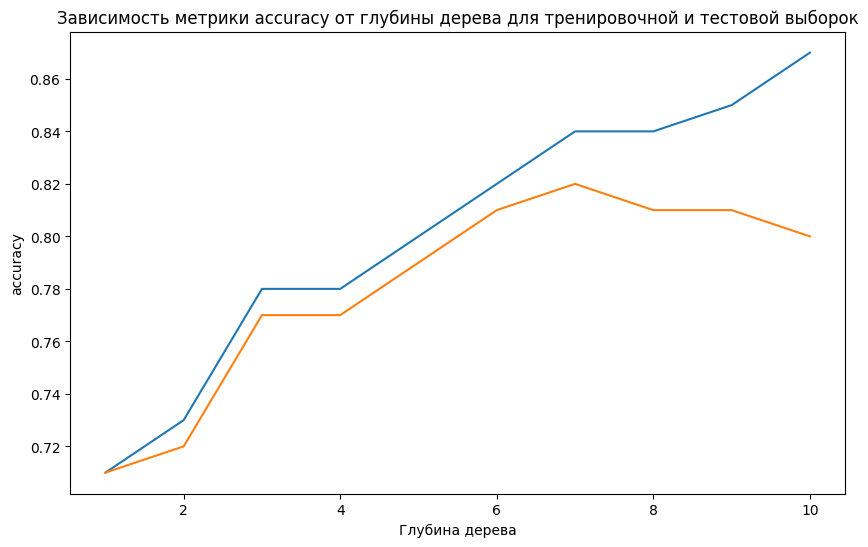

In [43]:
train = []
test = []

for i in range(1,11):
    dt = tree.DecisionTreeClassifier(
                                     criterion='entropy', 
                                     random_state=42, 
                                     max_depth=i
                                     )
    dt.fit(X_train_scaled, y_train)
    
    pred_train = dt.predict(X_train_scaled)
    train.append(round(metrics.accuracy_score(y_train, pred_train), 2))
    pred_test = dt.predict(X_test_scaled)
    test.append(round(metrics.accuracy_score(y_test, pred_test), 2))

line,ax = plt.subplots(figsize=(10,6))
sns.lineplot(x=range(1, 11), y=train)
sns.lineplot(x=range(1, 11), y=test)
ax.set_title("Зависимость метрики accuracy от глубины дерева для тренировочной и тестовой выборок", fontsize=12)
ax.set_xlabel ("Глубина дерева")
ax.set_ylabel ("accuracy")

In [59]:
dt = tree.DecisionTreeClassifier(
                                 criterion='entropy', 
                                 random_state=42, 
                                 max_depth=7
                                 )
dt.fit(X_train_scaled, y_train)

y_pred_dt = dt.predict(X_test_scaled)
print(f'Значение метрики accuracy для тестовой выборки при максимальной глубине 7: {round(metrics.accuracy_score(y_test, y_pred_dt), 3)}')
print()
print(f'Метрики для тестовой выборки: \n \n {(metrics.classification_report(y_test, y_pred_dt, digits=3))}')

Значение метрики accuracy для тестовой выборки при максимальной глубине 7: 0.819

Метрики для тестовой выборки: 
 
               precision    recall  f1-score   support

           0      0.841     0.816     0.828      1790
           1      0.794     0.822     0.808      1545

    accuracy                          0.819      3335
   macro avg      0.818     0.819     0.818      3335
weighted avg      0.819     0.819     0.819      3335



### Задание 5

In [61]:
# подберите оптимальные параметры с помощью gridsearch
from sklearn.model_selection import train_test_split, GridSearchCV

param_grid = {'min_samples_split': [2, 5, 7, 10],
              'max_depth':[3,5,7]
              }

grid_search = GridSearchCV(
    estimator=tree.DecisionTreeClassifier(random_state=42), 
    param_grid=param_grid,
    cv=5, 
    n_jobs = -1
)  

%time grid_search.fit(X_train_scaled, y_train) 

y_pred_grid = grid_search.predict(X_test_scaled)

print('f1_score на тестовом наборе: {:.2f}'.format(metrics.f1_score(y_test, y_pred_grid)))
print("Наилучшие значения гиперпараметров: {}".format(grid_search.best_params_))
print()
print(f'Метрики для тестовой выборки: \n \n {(metrics.classification_report(y_test, y_pred_grid, digits=3))}')

CPU times: total: 141 ms
Wall time: 237 ms
f1_score на тестовом наборе: 0.80
Наилучшие значения гиперпараметров: {'max_depth': 7, 'min_samples_split': 2}

Метрики для тестовой выборки: 
 
               precision    recall  f1-score   support

           0      0.834     0.816     0.825      1790
           1      0.792     0.812     0.802      1545

    accuracy                          0.814      3335
   macro avg      0.813     0.814     0.813      3335
weighted avg      0.814     0.814     0.814      3335



# Часть 5: Решение задачи классификации: ансамбли моделей и построение прогноза

### Задание 1

In [63]:
# обучите на ваших данных случайный лес
rf = ensemble.RandomForestClassifier(n_estimators = 100,
                                     criterion = 'gini',
                                     min_samples_leaf = 5,
                                     max_depth = 10,
                                     random_state = 42
)

rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

print(f'Метрики для тестовой выборки: \n \n{metrics.classification_report(y_test, y_pred_rf, digits=3)}')

Метрики для тестовой выборки: 
 
              precision    recall  f1-score   support

           0      0.852     0.823     0.837      1790
           1      0.803     0.835     0.819      1545

    accuracy                          0.828      3335
   macro avg      0.828     0.829     0.828      3335
weighted avg      0.829     0.828     0.829      3335



### Задания 2 и 3

In [64]:
# используйте для классификации градиентный бустинг и сравните качество со случайным лесом
gb = ensemble.GradientBoostingClassifier(
        learning_rate=0.05,
        n_estimators=300,
        min_samples_leaf = 5,
        max_depth=5,
        random_state=42
)

gb.fit(X_train_scaled, y_train)

y_pred_gb = gb.predict(X_test_scaled)
print(f'Метрики для тестовой выборки: \n \n{metrics.classification_report(y_test, y_pred_gb, digits=3)}')

Метрики для тестовой выборки: 
 
              precision    recall  f1-score   support

           0      0.850     0.822     0.836      1790
           1      0.802     0.832     0.817      1545

    accuracy                          0.827      3335
   macro avg      0.826     0.827     0.826      3335
weighted avg      0.828     0.827     0.827      3335



Градиентный бустинг не показал лучшего результата.

### Задание 4

In [65]:
# объедините уже известные вам алгоритмы с помощью стекинга 
estimators = [
    ('lr', linear_model.LogisticRegression(
            solver='sag',
            random_state=42,
            max_iter=1000)),
    ('dt', tree.DecisionTreeClassifier(
            criterion='entropy',
            random_state=42,
            max_depth=6)),
    ('gb', ensemble.GradientBoostingClassifier(
            learning_rate=0.05,
            n_estimators=300,
            min_samples_leaf = 5,
            max_depth=5,
            random_state=42))
]

clf = ensemble.StackingClassifier(
    estimators=estimators,
    final_estimator=linear_model.LogisticRegression(
        solver='sag',
        random_state=42,
        max_iter=1000
    ),
    n_jobs=-1
)

clf.fit(X_train_scaled, y_train)
y_pred_reg = clf.predict(X_test_scaled)

print(f'Метрики для тестовой выборки: \n \n{metrics.classification_report(y_test, y_pred_reg, digits=3)}')

Метрики для тестовой выборки: 
 
              precision    recall  f1-score   support

           0      0.834     0.830     0.832      1790
           1      0.804     0.809     0.807      1545

    accuracy                          0.820      3335
   macro avg      0.819     0.820     0.819      3335
weighted avg      0.820     0.820     0.820      3335



### Задание 5

Text(0, 0.5, 'Признаки')

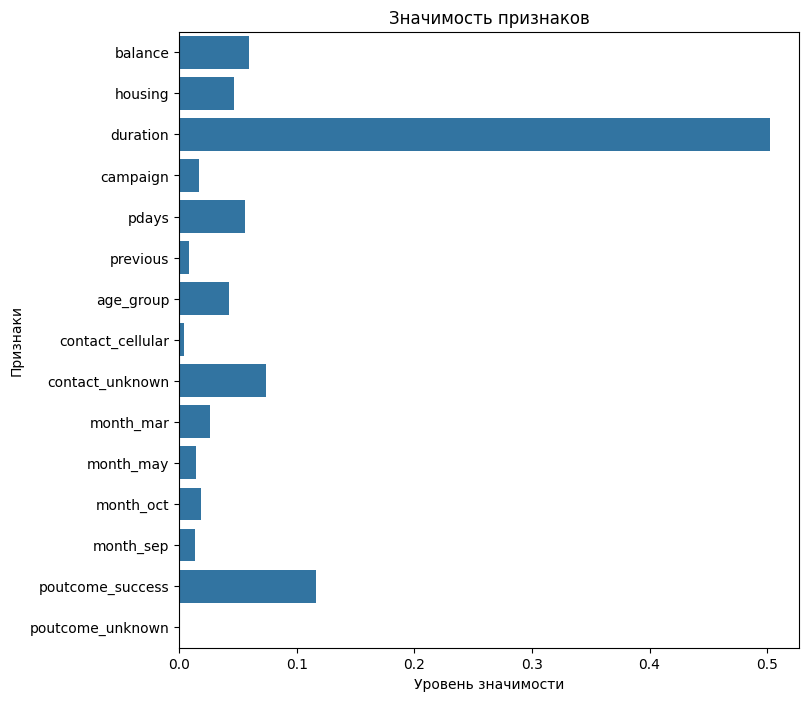

In [49]:
# оцените, какие признаки демонстрируют наибольшую  важность в модели градиентного бустинга
line,ax = plt.subplots(figsize=(8,8))
sns.barplot(x=gb.feature_importances_, y=selector_skb_cols)
ax.set_title('Значимость признаков', fontsize=12)
ax.set_xlabel ('Уровень значимости')
ax.set_ylabel ('Признаки')

Наибольшую важность демонстрируют признаки: duration (продолжительность контакта), poutcome_sucsess (успех в прошлой кампании), contact_unknown (тип контакта - неизвестен).

- Можно предположить, что чем длительнее контакт, тем больше удалось обсудить, а это положительно влияет на желание открыть депозит, в отличие от быстрых контактов, закончившиеся с большей вероятностью отказом.
- Также положительно влияет успех в прошлой кампании - если клиент уже соглашался ранее на условия открытия депозита, то вероятность согласиться в этот раз растет, так как условия уже известны и доверия к банку больше.
- Тип контакта - неизвестен может оказывать влияние, если с клиентом не смогли связаться, то есть предложение не поступало, клиент не мог на него согласиться.

### Задания 6,7,8

In [67]:
# реализуйте оптимизацию гиперпараметров с помощью Optuna
import optuna

def optuna_rf(trial):
  n_estimators = trial.suggest_int('n_estimators', 100, 200, 1)
  max_depth = trial.suggest_int('max_depth', 10, 30, 1)
  min_samples_leaf = trial.suggest_int('min_samples_leaf', 2, 10, 1)

  model = ensemble.RandomForestClassifier(n_estimators=n_estimators,
                                          max_depth=max_depth,
                                          min_samples_leaf=min_samples_leaf,
                                          random_state=42)
  
  model.fit(X_train_scaled, y_train)
  
  score = metrics.f1_score(y_train, model.predict(X_train_scaled))
  
  return score


study = optuna.create_study(study_name="RandomForestClassifier", direction="maximize")
study.optimize(optuna_rf, n_trials=20)

print("Наилучшие значения гиперпараметров {}".format(study.best_params))

model = ensemble.RandomForestClassifier(**study.best_params,random_state=42)
model.fit(X_train_scaled, y_train)
y_test_pred = model.predict(X_test_scaled)

print('f1_score на тестовом наборе: {:.2f}'.format(metrics.f1_score(y_test, y_test_pred)))

[I 2026-04-22 18:48:10,262] A new study created in memory with name: RandomForestClassifier
[I 2026-04-22 18:48:11,917] Trial 0 finished with value: 0.8901064495929869 and parameters: {'n_estimators': 151, 'max_depth': 20, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.8901064495929869.
[I 2026-04-22 18:48:13,098] Trial 1 finished with value: 0.8626408010012516 and parameters: {'n_estimators': 130, 'max_depth': 25, 'min_samples_leaf': 6}. Best is trial 0 with value: 0.8901064495929869.
[I 2026-04-22 18:48:14,101] Trial 2 finished with value: 0.8620150187734669 and parameters: {'n_estimators': 111, 'max_depth': 30, 'min_samples_leaf': 6}. Best is trial 0 with value: 0.8901064495929869.
[I 2026-04-22 18:48:15,635] Trial 3 finished with value: 0.8509570128647631 and parameters: {'n_estimators': 194, 'max_depth': 18, 'min_samples_leaf': 9}. Best is trial 0 with value: 0.8901064495929869.
[I 2026-04-22 18:48:17,211] Trial 4 finished with value: 0.8579021416288884 and parameters: {'n_

Наилучшие значения гиперпараметров {'n_estimators': 167, 'max_depth': 23, 'min_samples_leaf': 2}
f1_score на тестовом наборе: 0.82


In [68]:
print(f'Метрики для тестовой выборки: \n \n{metrics.classification_report(y_test, y_test_pred, digits=3)}')

Метрики для тестовой выборки: 
 
              precision    recall  f1-score   support

           0      0.855     0.811     0.832      1790
           1      0.793     0.841     0.816      1545

    accuracy                          0.825      3335
   macro avg      0.824     0.826     0.824      3335
weighted avg      0.826     0.825     0.825      3335



In [86]:
from sklearn.metrics import accuracy_score, f1_score

# Словарь с предсказаниями моделей (исправлены дубликаты)
models_pred = {
    'LogisticRegression': y_pred_lr,
    'DecisionTreeClassifier': y_pred_dt,
    'GridSearchCV': y_pred_grid,
    'RandomForestClassifier': y_pred_rf,
    'GradientBoostingClassifier': y_pred_gb,
    'StackingClassifier': y_pred_reg,
    'RandomForestClassifier + Optuna': y_test_pred,
}

# Собираем метрики
results = []
for name, y_pred in models_pred.items():
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred, average='binary')
    })

# СОЗДАЁМ DATAFRAME
results_df = pd.DataFrame(results)
results_df = results_df.round(3).sort_values('Accuracy', ascending=False)

# Стиль с градиентом
styled_df = results_df.style.background_gradient(cmap='RdYlGn', subset=['Accuracy', 'F1'])
styled_df = styled_df.format({'Accuracy': '{:.3f}', 'F1': '{:.3f}'})
styled_df = styled_df.set_properties(**{'font-size': '12pt', 'font-family': 'Arial'})
styled_df = styled_df.set_table_styles([
    {'selector': 'th', 'props': [('font-size', '12pt'), ('text-align', 'center'), ('background-color', '#333333')]},
    {'selector': 'caption', 'props': [('font-size', '14pt'), ('font-weight', 'bold'), ('margin-bottom', '10px')]}
])
styled_df = styled_df.set_caption('📊 Сравнение метрик моделей классификации')

display(styled_df)

,Model,Accuracy,F1
3,RandomForestClassifier,0.828,0.819
4,GradientBoostingClassifier,0.827,0.817
6,RandomForestClassifier + Optuna,0.825,0.816
5,StackingClassifier,0.820,0.807
1,DecisionTreeClassifier,0.819,0.808
2,GridSearchCV,0.814,0.802
0,LogisticRegression,0.805,0.777


**Общий вывод по проекту:**

1) В ходе исследования выделено 3 наиболее важных признака, влияющие на целевую переменную:
    - duration (продолжительность контакта в секундах) - оптимальная продолжительность контакта находится в диапазоне - до 5 минут;
    - poutcome_success (результат прошлой маркетинговой кампании) - success (успех, согласие);
    - contact_unknown (тип контакта с клиентом) - unknown (неизвестный).

    Можно сделать вывод, что для решения клиента открыть или нет депозит влияет в большей степени навыки коммуникации сотрудника банка.

2) Вторичные внутренние факторы для конкретного клиента:
    - job_student, job_retired (сфера занятости) - целевая аудитория это студенты и пенсионеры;
    - age_group (возрастная группа) - потенциальные группы - младше 31 и старше 60;
    - marital (семейное положение) - клиенты single;
    - month (месяц контакта с клиентом) - наиболее благоприятный месяц для открытия депозита - это декабрь, наименее удачный - май.
    - и другие факторы

3) Для решения задачи классификации в данном кейсе лучше всего себя показали 3 модели:
    - модель случайного леса со стартовыми параметрами
    - градиентного бустинга
    - случайного леса с подобранными гиперпараметрами методом Optuna